In [67]:
import datacube

import geopandas as gpd
from datetime import datetime, timedelta
import pandas as pd
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from affine import Affine
from datacube.utils.geometry import CRS
from datacube.utils.cog import write_cog
import rasterio.features
from pathlib import Path
from shapely.geometry import shape
from tempfile import TemporaryDirectory
import re
from skimage import morphology
from scipy import ndimage
import sys
sys.path.insert(1, '../../Temp_branch/dea-notebooks/Tools')
from dea_tools.datahandling import load_ard
from dea_tools.plotting import rgb, display_map
from dea_tools.bandindices import calculate_indices
from dea_tools.dask import create_local_dask_cluster
from dea_tools.spatial import xr_vectorize

# Create local dask cluster to improve data load time
client = create_local_dask_cluster(return_client=True)

/env/lib/python3.10/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 43055 instead
  warnings.warn(


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /user/cate.kooymans@ga.gov.au/proxy/43055/status,
Dashboard: /user/cate.kooymans@ga.gov.au/proxy/43055/status,Workers: 1
Total threads: 15,Total memory: 117.21 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:35689,Workers: 1
Dashboard: /user/cate.kooymans@ga.gov.au/proxy/43055/status,Total threads: 15
Started: Just now,Total memory: 117.21 GiB
Comm: tcp://127.0.0.1:33973,Total threads: 15
Dashboard: /user/cate.kooymans@ga.gov.au/proxy/36077/status,Memory: 117.21 GiB
Nanny: tcp://127.0.0.1:37929,


In [68]:
dc = datacube.Datacube(app="Burnt_area_mapping")

In [69]:
def display_geometry_on_map(geom, zoom_bias=0):
    """
    Plots a datacube.utils.geometry.Geometry object on a folium map.

    Parameters
    ----------
    geom : datacube.utils.geometry.Geometry
        A geometry object to plot.
    zoom_bias : int or float
        Optional zoom adjustment.

    Returns
    -------
    folium.Map
        Interactive map with the geometry overlay.
    """
    import folium
    import numpy as np
    from pyproj import Transformer


    # Transform geometry to EPSG:4326 if needed
    if geom.crs.to_epsg() != 4326:
        geom = geom.to_crs('EPSG:4326')

    # Prepare list of polygons
    polygons = []
    if geom.geom.geom_type == 'Polygon':
        polygons.append(list(geom.geom.exterior.coords))
    elif geom.geom.geom_type == 'MultiPolygon':
        for poly in geom.geom.geoms:
            polygons.append(list(poly.exterior.coords))
    else:
        raise ValueError(f"Unsupported geometry type: {geom.geom.geom_type}")

    # Flatten all coordinates for center calculation
    all_coords = [coord for poly in polygons for coord in poly]
    lat_lon_coords = [(y, x) for x, y in all_coords]  # Folium expects (lat, lon)

    # Calculate center and zoom
    lats, lons = zip(*lat_lon_coords)
    center = [np.mean(lats), np.mean(lons)]
    zoom_level = 10 + zoom_bias

    # Create map
    m = folium.Map(location=center, zoom_start=zoom_level,
                   tiles="http://mt1.google.com/vt/lyrs=y&z={z}&x={x}&y={y}",
                   attr="Google")

    # Add each polygon to the map
    for poly_coords in polygons:
        lat_lon_poly = [(y, x) for x, y in poly_coords]
        folium.Polygon(locations=lat_lon_poly, color="blue", fill=True, fill_opacity=0.4).add_to(m)

    # Add lat-lon popup
    folium.LatLngPopup().add_to(m)

    return m

def find_latest_valid_pixel(dataset):
    """
    For a multi-temporal xarray Dataset (masked for clouds/contiguity),
    return the latest clear value for each pixel across all bands.
    Output: Dataset with same bands, no time dimension.
    """
    # Ensure 'time' is a dimension
    if 'time' not in dataset.dims:
        raise ValueError("Dataset must have a 'time' dimension")

    # Convert time to numeric for comparison
    time_numeric = xr.DataArray(dataset['time'].astype('datetime64[ns]').astype(np.int64), dims='time')

    # Create mask for valid values (non-NaN)
    valid_mask = ~np.isnan(dataset['nbart_green'])

    # Multiply mask by time to get numeric time where valid, else 0
    valid_times = valid_mask * time_numeric

    # Find latest valid time for each pixel
    latest_valid_time = valid_times.max(dim='time')

    # Create mask for latest time
    latest_mask = valid_times == latest_valid_time

    # Select latest valid values for each band
    latest_values = dataset.where(latest_mask).max(dim='time')

    return latest_values

def clean_name(name: str) -> str:
    """this takes a tring and ensures it dosn't contain any punctuation, numbers or special characters. then replaces spaces with underscore
    this is for the purpose of turning long, annoying fire names into someing that can be used to save files with, no manual fussing requiered"""
    # Remove numbers and special characters (keep only letters and spaces)
    cleaned = re.sub(r'[^A-Za-z\s]', '', name)
    # Replace spaces with underscores
    cleaned = re.sub(r'\s+', '_', cleaned)
    return cleaned

def is_valid_date_format(s):
    # Regex for YYYY-MM-DD where:
    # YYYY = 4 digits, MM = 01-12, DD = 01-31
    pattern = r'^\d{4}-(0[1-9]|1[0-2])-(0[1-9]|[12]\d|3[01])$'
    return bool(re.match(pattern, s))


def process_date(date):
    """check the format for a date is as desiered 'YYYY-MM-DD', If it is not then format assuming it's 
    a valid date either as YYYYMMDD or YYYYMMDDhhmmss.
    otherwise return None. """
    if date == None:
        return 
    elif is_valid_date_format(date) == True:
        return date
    elif bool(re.match(r'^\d+$', date)) == True:
        return f'{date[0:4]}-{date[4:6]}-{date[6:8]}'
    else:
        return


In [70]:
#open burn polygon
polygon_path = '/home/jovyan/gdata1/projects/Hazards/burn_severity/test_polygons_from_Aurora/last_boundaries_20251104/last_boundaries_20251104.shp'
# gdata1/projects/Hazards/burn_severity/extent_polygons/Buji_bim.shp
# Hazards/Burn_severity/burn_polygons/mystery_WA.shp
# Hazards/Burn_severity/burn_polygons/Adaminaby_complex.shp


all_poly = gpd.read_file(polygon_path)
all_poly

,fire_id,fire_name,fire_type,ignition_d,capt_date,capt_metho,area_ha,perim_km,state,agency,date_retri,date_proce,geometry
0,a518823f-bdea-4299-877b-7b44328d243d,None,None,20251026201856,20251026212818,FIREMAPPER,5625.38,29.78,QLD,Qld Fire and Emergency Services,20251027081500,2025-11-03,"POLYGON ((150.60643 -27.80656, 150.60634 -27.8..."
1,f1f59811-cc15-4ea1-9ddc-7afb7ac141d3,None,None,20251026183608,20251026183608,FIREMAPPER,40.01,3.30,QLD,Qld Fire and Emergency Services,20251027081500,2025-11-03,"POLYGON ((151.32249 -25.42251, 151.32325 -25.4..."
2,c5fe4446-1f4b-468b-a063-106d85b0da4a,None,None,20251026154651,20251026171837,FIREMAPPER,18.60,2.28,QLD,Qld Fire and Emergency Services,20251027081500,2025-11-03,"POLYGON ((151.81505 -24.49674, 151.81515 -24.4..."
3,627264,"TICKLE LANE, TUCKI TUCKI NSW",Bushfire,None,20251027100500,None,0.50,0.38,NSW,Rural Fire Service,20251027101500,2025-11-03,"POLYGON ((153.30252 -28.93938, 153.30273 -28.9..."
4,627217,"MAIN ROAD, YARRATT FOREST",Bushfire,None,20251027073100,None,20.27,1.96,NSW,Rural Fire Service,20251027081500,2025-11-03,"POLYGON ((152.41953 -31.82124, 152.41974 -31.8..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...
406,c066c345-9fbe-42c7-be95-36e438a3b0bc,None,None,20251009131850,20251009131850,FIREMAPPER,0.08,0.12,QLD,Qld Fire and Emergency Services,20251020021500,2025-11-03,"POLYGON ((151.96714 -26.97870, 151.96714 -26.9..."
407,7969FCFD-8997-4C0D-9D03-BCAFBC9326C0,None,None,20251008140649,20251008140649,MICA,49.26,3.35,QLD,Qld Fire and Emergency Services,20251020021500,2025-11-03,"POLYGON ((148.49548 -25.38880, 148.49463 -25.3..."
408,2490C830-667D-43D7-97E2-465E772BC1DE,None,None,20251007161601,20251007161601,MICA,34.69,2.61,QLD,Qld Fire and Emergency Services,20251020021500,2025-11-03,"POLYGON ((148.49094 -25.39306, 148.48772 -25.3..."
409,624719,Motorway Link Stage 2,Prescribed Burn,None,20251019200800,None,18.95,1.91,NSW,Rural Fire Service,20251020020000,2025-11-03,"POLYGON ((151.46351 -33.22228, 151.46392 -33.2..."


In [71]:
poly = all_poly.iloc[0]

In [72]:
poly

fire_id                    a518823f-bdea-4299-877b-7b44328d243d
fire_name                                                  None
fire_type                                                  None
ignition_d                                       20251026201856
capt_date                                        20251026212818
capt_metho                                           FIREMAPPER
area_ha                                                 5625.38
perim_km                                                  29.78
state                                                       QLD
agency                          Qld Fire and Emergency Services
date_retri                                       20251027081500
date_proce                                           2025-11-03
geometry      POLYGON ((150.6064259998667 -27.80656099993823...
Name: 0, dtype: object

In [73]:
#define attribute list
#this is all the attibutes we need to copy
attribute_list = ['fire_id',                                               
                    'fire_name',
                    'fire_type',
                    'ignition_d',
                    'capt_date',
                    'capt_metho',
                    'area_ha',
                    'perim_km',
                    'state',
                    'agency',
                    'date_retri',
                    'date_proce']

date_atts = ['ignition_d','capt_date','date_retri','date_proce']

#this is the correct name for all attibutes .shp shortens attribute name
attribute_list_dict = {'fire_id' : 'fire_id',                                               
                    'fire_name': 'fire_name',
                    'fire_type' : 'fire_type',
                    'ignition_d': 'ignition_date',
                    'capt_date': 'capt_date',
                    'capt_metho': 'capt_method',
                    'area_ha' : 'area_ha',
                    'perim_km': 'perim_km',
                    'state': 'state',
                    'agency': 'agency',
                    'date_retri': 'date_retrieved',
                    'date_proce': 'date_processed'}


In [74]:
# try:
#     if len(poly) > 1:
#         poly = poly.dissolve(by='fire_id')
#         #disolve by fire id

# except TypeError as e:
#     pass
 

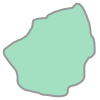

In [75]:
#this is how we will save the file
fire_id_forsave = f'{poly.fire_id}_{poly.date_proce}'

# Specifying coordinate reference system of the polygon.
gpgon = datacube.utils.geometry.Geometry(poly.geometry, crs=all_poly.crs)
gpgon

In [76]:
display_geometry_on_map(gpgon)

In [93]:
# Fire event date
fire_date = process_date(poly.ignition_d)

if fire_date == None:
    #sometimes this is empty. try capture date
    fire_date = process_date(poly.capture_da)
    if fire_date == None:
        print ('no start date - skip')
        # I was just skipping this polygon if it lacks a valid date


extinguish_date = process_date(poly.date_retri)
        
        #find year for landcover data load
        
    
landcover_year = str(int(fire_date[0:4])-1)

In [79]:
# fire_date = '2016-02-10' #manually set fire date for mater behavior ananlysis
# extinguish_date = '2019-12-21'

In [80]:
#Harcoding in WA's buffers, pre-immage witin 50 days before, post fire is 60 days after

# Calculate the start and end date for baseline data load
start_date_pre = datetime.strftime(
    ((datetime.strptime(fire_date, '%Y-%m-%d')) - timedelta(days=50)), '%Y-%m-%d')
end_date_pre = datetime.strftime(
    ((datetime.strptime(fire_date, '%Y-%m-%d')) - timedelta(days=1)),
    '%Y-%m-%d')

# Calculate start end date for post fire data load
if extinguish_date == 'None':
    #if not extinguish date given assume 15 days
    start_date_post = datetime.strftime(
        ((datetime.strptime(fire_date, '%Y-%m-%d')) + timedelta(days=15)),
        '%Y-%m-%d')
else:
    #start date for post fire data load is extinguish date
    start_date_post = extinguish_date

#TO DO decide what our post fire max timeframe will be
end_date_post = datetime.strftime(
    ((datetime.strptime(start_date_post, '%Y-%m-%d')) + timedelta(days=60)),
    '%Y-%m-%d')

In [81]:
print(start_date_pre, end_date_pre)

2025-09-06 2025-10-25


In [82]:
resolution = (-10, 10)
measurements = ['nbart_green','nbart_nir_1','nbart_swir_2','nbart_swir_3','oa_nbart_contiguity','oa_s2cloudless_mask']

output_crs = 'EPSG:3577'

In [83]:
# Load all data in baseline period available from ARD data
baseline = load_ard(dc=dc,
                        products=['ga_s2am_ard_3', 'ga_s2bm_ard_3','ga_s2cm_ard_3'],
                        geopolygon=gpgon,
                        cloud_mask = 's2cloudless',
                        # x=study_area_lon,
                        # y=study_area_lat,
                        time=(start_date_pre, end_date_pre),
                        measurements=measurements,
                        min_gooddata=0.99, #we want no clouds for the pre-fire image
                        output_crs=output_crs,
                        resolution=resolution,
                        group_by='solar_day',
                        dask_chunks= {"x": 2048, "y": 2048})

if baseline.time.size == 0:
    #try load again with less strict controls on clouds. buffer out more 
    filters = [("dilation", 15)]
    baseline = load_ard(dc=dc,
                        products=['ga_s2am_ard_3', 'ga_s2bm_ard_3','ga_s2cm_ard_3'],
                        geopolygon=gpgon,
                        cloud_mask = 's2cloudless',
                        # x=study_area_lon,
                        # y=study_area_lat,
                        time=(start_date_pre, end_date_pre),
                        measurements=measurements,
                        mask_filters=filters,
                        min_gooddata=0.20,
                        output_crs=output_crs,
                        resolution=resolution,
                        group_by='solar_day',
                        dask_chunks= {"x": 2048, "y": 2048})

    #GENERATE composite baseline from avalible data
    closest_Bl = find_latest_valid_pixel(baseline)

else:
    #if len of 99% cloud free is NOT 0
    # (-1 is the most recent image from the stack)
    closest_Bl = baseline.isel(time=-1)

#generate empty xr for debug layer
debug_layer_blank = xr.ones_like(closest_Bl.nbart_green)

Finding datasets
    ga_s2am_ard_3
    ga_s2bm_ard_3
    ga_s2cm_ard_3
Counting good quality pixels for each time step using s2cloudless


/env/lib/python3.10/site-packages/rasterio/warp.py:387: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dest = _reproject(


Filtering to 13 out of 20 time steps with at least 99.0% good quality pixels
Applying s2cloudless pixel quality/cloud mask
Returning 13 time steps as a dask array


In [84]:
# rgb(closest_Bl, bands=['nbart_swir_2', 'nbart_nir_2', 'nbart_green'])

In [85]:
#Calculate NBR
pre_nbr = calculate_indices(closest_Bl, 
                             index='NBR', 
                             collection='ga_s2_3', 
                             drop=True)

Dropping bands ['nbart_green', 'nbart_nir_1', 'nbart_swir_2', 'nbart_swir_3', 'oa_nbart_contiguity', 'oa_s2cloudless_mask']


In [86]:
# Load post-fire data from all Sentinel 2 satellites
post = load_ard(dc=dc,
                products=['ga_s2am_ard_3', 'ga_s2bm_ard_3','ga_s2cm_ard_3'],
                geopolygon=gpgon,
                cloud_mask = 's2cloudless',
                # x=study_area_lon,
                # y=study_area_lat,
                time=(start_date_post, end_date_post),
                min_gooddata=0.90,
                measurements=measurements,
                output_crs=output_crs,
                resolution=resolution,
                group_by='solar_day',
                dask_chunks= {"x": 2048, "y": 2048})

Finding datasets
    ga_s2am_ard_3
    ga_s2bm_ard_3
    ga_s2cm_ard_3
Counting good quality pixels for each time step using s2cloudless
Filtering to 4 out of 7 time steps with at least 90.0% good quality pixels
Applying s2cloudless pixel quality/cloud mask
Returning 4 time steps as a dask array


In [87]:
# rgb(post, col='time', bands=['nbart_swir_2', 'nbart_nir_2', 'nbart_green'])

In [88]:

#calculate NBR for post fire
post_nbr = calculate_indices(post, 
                             index='NBR', 
                             collection='ga_s2_3', 
                             drop=True)

#calculate MINIMUM nbr in time stack
max_nbr = post_nbr.min('time')

Dropping bands ['nbart_green', 'nbart_nir_1', 'nbart_swir_2', 'nbart_swir_3', 'oa_nbart_contiguity', 'oa_s2cloudless_mask']


In [89]:
#calculate the delta NBR

deltaNBR =  pre_nbr - max_nbr

In [96]:
landcover = dc.load(
                product='ga_ls_landcover_class_cyear_3',
                geopolygon=gpgon,
                time=(landcover_year),
                output_crs=output_crs,
                resolution=resolution,
                group_by='solar_day',
                dask_chunks= {"x": 2048, "y": 2048})
landcover = landcover.isel(time=0)

In [97]:
#remove time dimention

grass_class = [3, 14, 15, 16, 17, 18, 21, 32, 33, 34, 35, 36, 39, 50, 51, 52, 53, 54, 57, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 94, 95, 96, 97]
#these are the land Cover classes that are grass dominated

grass_mask = xr.zeros_like(landcover.level4)

for x in grass_class:
    x_pixels = (landcover.level4 == x ) * 1

    grass_mask = grass_mask + x_pixels

In [98]:
# apply thesholds to get severity classes
#the different severity classes are labled by stacking the extents together

low = (deltaNBR >= 0.1) * 2
medium = (deltaNBR >= 0.27) * 1
high = (deltaNBR >= 0.44) * 1
Very_high = (deltaNBR >= 0.66) * 1

severity_woody = (low + medium + high + Very_high) #combine the woody severity classes
severity_woody = (severity_woody.NBR.where(grass_mask== 0, 0))
#mask woody burn severity by grass extent

In [99]:
severity_grass = grass_mask.where(deltaNBR.NBR >= 0.1, 0)
#this gives us where both grass and burnt are true = grass burn extent.

severity = severity_woody + severity_grass
#combine woody and grass burn classes

In [100]:
# severity.plot()

The above gives us our severity classes. next steps is to determine 1) water extent 2) cloud and 3)contiguity errors. then apply those to severity as a 'no data class'

In [101]:
#calculate NBR for post fire
post_MNDWI = calculate_indices(post, 
                             index='MNDWI', 
                             collection='ga_s2_3', 
                             drop=True)

max_MNDWI = post_MNDWI.max('time')
# max_MNDWI.MNDWI.plot()

post_water = debug_layer_blank.where(max_MNDWI.MNDWI > 0, 0) #define water extent
#  #find the wettest observation per pixel


Dropping bands ['nbart_green', 'nbart_nir_1', 'nbart_swir_2', 'nbart_swir_3', 'oa_nbart_contiguity', 'oa_s2cloudless_mask']


In [102]:
#generate de-bug layer (and mask ^ result if requiered)
# mask for pre-fire cloud and and add that to de-bug

new_debug = post_water + (debug_layer_blank.where(closest_Bl.oa_s2cloudless_mask == 2, 0))*10 #add cloud to debug 

#mask for persistant post-fire cloud
#first remove contiguity from cloudmask
post_cloud = post.oa_s2cloudless_mask.where(post.oa_s2cloudless_mask >= 1, 1)
persistant_cloud = post_cloud.min('time') #find any pixels that have had no clear observation accross stack

new_debug = new_debug + (debug_layer_blank.where(persistant_cloud == 2, 0))*100 #add post-fire cloud to debug


In [103]:
#now contiguity
#pre-fire contiguity

new_debug = new_debug + (debug_layer_blank.where(closest_Bl.oa_nbart_contiguity != 1, 0))*1000

#post-fire contiguity
post_contiguity = post.oa_nbart_contiguity.where(post.oa_nbart_contiguity == 1, 0) #turns all non 1 values to 0
persistant_cont = post_contiguity.max('time') #find maximum contiguity value over stack

new_debug = new_debug + (debug_layer_blank.where(persistant_cont != 1, 0))*10000 # add post fire contiguity to de-bug


In [104]:
# new_debug.plot(cmap='tab20', vmax=100) #it goes up to 10000 but you can't see anything if you iclude that in visualisation range

In [105]:
Severity = severity.where(new_debug ==0, 6) #ensure dataclasses from de-bug are no data 

If you want to save the geotiff output uncomment the below

In [106]:
# write_cog(severity.compute(), fname= 'results/burn_severity_water_behavior_test.tif')

In [107]:
# convert to vectors
severity_vectors = xr_vectorize(severity, attribute_col='severity',  crs=output_crs)

#reproject to EPSG 4283
severity_vectors = severity_vectors.to_crs('EPSG:4283')

In [109]:
#clip to polygon
cliped_severity_vectors = severity_vectors.clip(poly.geometry)


In [110]:
#dissolve to join all polygons with same severity classes
aggrigated_severity = cliped_severity_vectors.dissolve(by='severity')

In [115]:
# give output polygons the extent polygon's attributes
if aggrigated_severity.empty == True:
    print('she empty')

# give output polygons the extent polygon's attributes

for att in attribute_list:
    if att in date_atts:
        print(poly[att])
        aggrigated_severity[attribute_list_dict[att]] = process_date(poly[att])
    else: 
        aggrigated_severity[attribute_list_dict[att]] = poly[att]

# Save polygons to file
aggrigated_severity.to_file(f'results/DEA_burn_severity_{fire_id_forsave}.json')

20251026201856
20251026212818
20251027081500
2025-11-03


In [111]:
#save de-bug layer
write_cog(new_debug.compute(), fname= f'results/debug_layer_{fire_id_forsave}.tif')



PosixPath('results/debug_layer_a518823f-bdea-4299-877b-7b44328d243d_2025-11-03.tif')

In [ ]:
# post.isel(time=0).to_array()